# Demographic Trends in Barcelona: Births and Deaths Analysis

## A data analysis project exploring birth and death patterns across Barcelona using Python.

In [4]:
#### Author: Pol Serra Pozas  
#### Applied Statistics student with an academic background in Pharmacy and Nutrition, with an interest in data analysis and health-related research.

## Project Description

This notebook combines **narrative explanations** and **code** to present the full data analysis workflow.

Text cells are used to **explain the context, methodology and interpretation of the results**.  
Code cells include comments that **describe and justify each step of the analysis**.

## INTRODUCTION

In recent decades, one of the most concerning social trends affecting many developed societies — and Barcelona is no exception — is the growing imbalance between the number of births and deaths. The combination of low birth rates and a progressively aging population raises demographic, economic and social concerns, especially in a dense and diverse city such as Barcelona.

Given this context, several relevant questions arise:

- Are there neighborhoods where births outnumber deaths?
- Are there areas where deaths clearly exceed births?
- Can territorial patterns be identified in this demographic balance?

This project does not aim to provide definitive answers or fully explain the causes of this phenomenon. Instead, it focuses on performing an **exploratory analysis of public data from the city of Barcelona** in order to identify potential trends and differences across neighborhoods and districts in terms of:

- The number of recorded births  
- The number of recorded deaths  

This **modest yet rigorous approach** aims to provide an initial overview of the demographic balance at a territorial level within Barcelona, helping to better understand which areas exhibit relatively “younger” or “older” dynamics based on the relationship between births and deaths.

## Dataset Description

This project uses two public datasets from the Open Data BCN portal to analyze the demographic balance of the city of Barcelona based on recorded births and deaths over time.

[**Dataset 1: Births in the city of Barcelona**](https://opendata-ajuntament.barcelona.cat/data/ca/dataset/pad_nai_mdbas/resource/43b15838-3724-4dae-a096-1eaf4a345ef7)  
This dataset contains the number of births in Barcelona per year, based on the Municipal Population Register. It is a demographic dataset whose main quantitative variables include the reference year and the total annual number of births in the city.

[**Dataset 2: Deaths in the city of Barcelona**](https://opendata-ajuntament.barcelona.cat/data/ca/dataset/pad_def_mdbas)  
This dataset includes the number of deaths in Barcelona per year, also based on the Municipal Population Register. Similarly to the births dataset, its main quantitative variables are the reference year and the total annual number of deaths in the city.

The combined use of these two datasets allows for the calculation and analysis of key demographic indicators, such as the natural population balance (the difference between births and deaths) over time.

**All the analysis presented in this project is based on data corresponding to the year 2024.**

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Import necessary libraries for data analysis and visualization

In [6]:
import requests

base_url = "https://opendata-ajuntament.barcelona.cat/data/api/action/datastore_search?resource_id="

resource_naixements = "43b15838-3724-4dae-a096-1eaf4a345ef7" 

n_records = 1067                         

resposta = requests.get(f"{base_url}{resource_naixements}", 
                        params = {"limit": n_records})
if resposta.status_code == 200:
    data_naix = resposta.json()
else:
    print("Error while downloading data")

In [7]:
import requests

base_url = "https://opendata-ajuntament.barcelona.cat/data/api/action/datastore_search?resource_id="

resource_defuncions = "8f03667c-863b-4507-a6cd-070b868dd941" 

n_records = 1068                         

resposta = requests.get(f"{base_url}{resource_defuncions}", 
                        params = {"limit": n_records})
if resposta.status_code == 200:
    data_defuncions = resposta.json()
else:
    print("Error while downloading data")

# Load demographic datasets (births and deaths) from the Open Data BCN portal

In [8]:
defuncions=pd.DataFrame(data_defuncions['result']['records'])
defuncions.to_csv('defuncions_BCN.csv',index=False) # Check that the datasets have been loaded correctly

In [9]:
NAIX=pd.DataFrame(data_naix['result']['records'])
NAIX.to_csv('naixements_BCN.csv',index=False) # Verify that the datasets have been loaded correctly

In [10]:
print(NAIX.head());print(defuncions.head())

  Codi_Districte Nom_Districte Nom_Barri AEB Seccio_Censal Valor Codi_Barri  \
0              1  Ciutat Vella  el Raval   1          1001     7          1   
1              1  Ciutat Vella  el Raval   1          1002    10          1   
2              1  Ciutat Vella  el Raval   2          1003    41          1   
3              1  Ciutat Vella  el Raval   2          1004    22          1   
4              1  Ciutat Vella  el Raval   3          1005    19          1   

   _id   Any  
0    1  2024  
1    2  2024  
2    3  2024  
3    4  2024  
4    5  2024  
  Codi_Districte Nom_Districte Nom_Barri AEB Seccio_Censal Valor Codi_Barri  \
0              1  Ciutat Vella  el Raval   1          1001     9          1   
1              1  Ciutat Vella  el Raval   1          1002    18          1   
2              1  Ciutat Vella  el Raval   2          1003    22          1   
3              1  Ciutat Vella  el Raval   2          1004     9          1   
4              1  Ciutat Vella  el Raval

In [11]:
DEFU=defuncions.drop(columns=['Codi_Districte','Nom_Districte','Nom_Barri','AEB','Codi_Barri','_id'])
NAIX=NAIX.drop(columns=['AEB','_id'])
DEFU.rename(columns={'Valor':'Defuncions'},inplace=True)
NAIX.rename(columns={'Valor':'Naixements'},inplace=True)
print(DEFU.head());print(NAIX.head())

# In the births dataset, additional variables are kept as they are relevant for subsequent analysis.

# Unnecessary columns are removed using .drop(), and selected columns are renamed for clarity and consistency.

  Seccio_Censal Defuncions   Any
0          1001          9  2024
1          1002         18  2024
2          1003         22  2024
3          1004          9  2024
4          1005         17  2024
  Codi_Districte Nom_Districte Nom_Barri Seccio_Censal Naixements Codi_Barri  \
0              1  Ciutat Vella  el Raval          1001          7          1   
1              1  Ciutat Vella  el Raval          1002         10          1   
2              1  Ciutat Vella  el Raval          1003         41          1   
3              1  Ciutat Vella  el Raval          1004         22          1   
4              1  Ciutat Vella  el Raval          1005         19          1   

    Any  
0  2024  
1  2024  
2  2024  
3  2024  
4  2024  


In [12]:
DEFU_NAIX=pd.merge(NAIX,DEFU,on=['Seccio_Censal','Any'])
DEFU_NAIX
# Merge the datasets using census section and year as common identifiers

,Codi_Districte,Nom_Districte,Nom_Barri,Seccio_Censal,Naixements,Codi_Barri,Any,Defuncions
0,1,Ciutat Vella,el Raval,1001,7,1,2024,9
1,1,Ciutat Vella,el Raval,1002,10,1,2024,18
2,1,Ciutat Vella,el Raval,1003,41,1,2024,22
3,1,Ciutat Vella,el Raval,1004,22,1,2024,9
4,1,Ciutat Vella,el Raval,1005,19,1,2024,17
...,...,...,...,...,...,...,...,...
1062,10,Sant Martí,la Verneda i la Pau,10139,6,73,2024,17
1063,10,Sant Martí,la Verneda i la Pau,10140,9,73,2024,18
1064,10,Sant Martí,la Verneda i la Pau,10141,..,73,2024,9
1065,10,Sant Martí,la Verneda i la Pau,10142,12,73,2024,23


In [13]:
ordre_columnes = [
    "Nom_Districte",
    "Codi_Districte",
    "Nom_Barri",
    "Codi_Barri",
    "Seccio_Censal",
    "Any",
    "Naixements",
    "Defuncions"
]

Defuncions_Naixements = DEFU_NAIX[ordre_columnes]
Defuncions_Naixements

# Specify the desired column order for the dataset
# Reorganize the table accordingly

,Nom_Districte,Codi_Districte,Nom_Barri,Codi_Barri,Seccio_Censal,Any,Naixements,Defuncions
0,Ciutat Vella,1,el Raval,1,1001,2024,7,9
1,Ciutat Vella,1,el Raval,1,1002,2024,10,18
2,Ciutat Vella,1,el Raval,1,1003,2024,41,22
3,Ciutat Vella,1,el Raval,1,1004,2024,22,9
4,Ciutat Vella,1,el Raval,1,1005,2024,19,17
...,...,...,...,...,...,...,...,...
1062,Sant Martí,10,la Verneda i la Pau,73,10139,2024,6,17
1063,Sant Martí,10,la Verneda i la Pau,73,10140,2024,9,18
1064,Sant Martí,10,la Verneda i la Pau,73,10141,2024,..,9
1065,Sant Martí,10,la Verneda i la Pau,73,10142,2024,12,23


Once the final dataset containing births and deaths has been obtained, we can proceed to compute **basic statistical measures**.

To do so, we use functions that allow us to quickly obtain **key insights** into the behavior of these variables.

## BASIC STATISTICS

First, the initial step consists of converting the relevant variables into **numeric format**, as they are currently stored as strings. This transformation is necessary to perform **basic statistical analysis** and generate subsequent visualizations.

In [14]:
Defuncions_Naixements["Naixements"]  = pd.to_numeric(Defuncions_Naixements["Naixements"], errors="coerce")
Defuncions_Naixements["Defuncions"]  = pd.to_numeric(Defuncions_Naixements["Defuncions"], errors="coerce")

# Convert selected variables to numeric format for analysis
# This ensures that variables stored as strings are properly treated as numeric values

In [15]:
# Compute basic statistical measures for births and deaths
Defuncions_Naixements[["Naixements", "Defuncions"]].describe()

# The "describe()" function provides a summary of key statistics.
# Alternatively, individual statistics can be computed separately:
# Defuncions_Naixements[["Naixements", "Defuncions"]].mean()
# Defuncions_Naixements[["Naixements", "Defuncions"]].std()
# Defuncions_Naixements[["Naixements", "Defuncions"]].min()
# Defuncions_Naixements[["Naixements", "Defuncions"]].quantile([0.25, 0.5, 0.75])

,Naixements,Defuncions
count,978.000000,1044.000000
mean,11.102249,13.978927
std,5.272490,6.033745
min,5.000000,5.000000
25%,7.000000,10.000000
50%,10.000000,13.000000
75%,13.000000,17.000000
max,47.000000,61.000000


Based on the basic statistics, we observe that, **in absolute terms**, there are **more deaths than births per census section**. The maximum number of deaths is 61 individuals, while the maximum number of births is 47.

The minimum values are the same in both cases (5), but **the median already shows a clear difference**: 10 births compared to 13 deaths. This indicates that, in a “typical” census section, slightly more deaths are recorded than births.

The mean values (11.1 births and 14.0 deaths) and standard deviations are also relatively similar, suggesting that **both variables exhibit a fairly homogeneous distribution without extreme outliers**, although the variability in deaths is slightly higher.

To assess the **balance between births and deaths**, that is, whether more people were born or died in a given census section during *2024*, a new variable is introduced.

This variable is computed as the difference between births and deaths. A **positive value** indicates that there are **more births than deaths** in that census section, while a **negative value** indicates that **deaths exceed births**.

Additionally, this variable allows for the creation of visualizations to analyze the distribution of this balance and identify whether positive or negative values are more frequent.

In [16]:
Defuncions_Naixements['Balanç Demogràfic'] = Defuncions_Naixements['Naixements'] - Defuncions_Naixements['Defuncions']

# Create a new variable representing the demographic balance (births minus deaths)
# No additional type conversion is required, as both variables are already numeric

Defuncions_Naixements[["Balanç Demogràfic"]].describe()

,Balanç Demogràfic
count,957.000000
mean,-3.059561
std,7.325773
min,-54.000000
25%,-7.000000
50%,-3.000000
75%,1.000000
max,25.000000


With the demographic balance variable, we can observe that, although there is *some dispersion*, **both the mean and the median are negative**, indicating that in most cases there are **more deaths than births**.

*The fact that the mean and median are similar suggests that there are no extreme values significantly distorting the distribution.*

## DATA VISUALIZATION

**DEMOGRAPHIC BALANCE**

In [17]:
Defuncions_Naixements

,Nom_Districte,Codi_Districte,Nom_Barri,Codi_Barri,Seccio_Censal,Any,Naixements,Defuncions,Balanç Demogràfic
0,Ciutat Vella,1,el Raval,1,1001,2024,7.0,9.0,-2.0
1,Ciutat Vella,1,el Raval,1,1002,2024,10.0,18.0,-8.0
2,Ciutat Vella,1,el Raval,1,1003,2024,41.0,22.0,19.0
3,Ciutat Vella,1,el Raval,1,1004,2024,22.0,9.0,13.0
4,Ciutat Vella,1,el Raval,1,1005,2024,19.0,17.0,2.0
...,...,...,...,...,...,...,...,...,...
1062,Sant Martí,10,la Verneda i la Pau,73,10139,2024,6.0,17.0,-11.0
1063,Sant Martí,10,la Verneda i la Pau,73,10140,2024,9.0,18.0,-9.0
1064,Sant Martí,10,la Verneda i la Pau,73,10141,2024,NaN,9.0,NaN
1065,Sant Martí,10,la Verneda i la Pau,73,10142,2024,12.0,23.0,-11.0


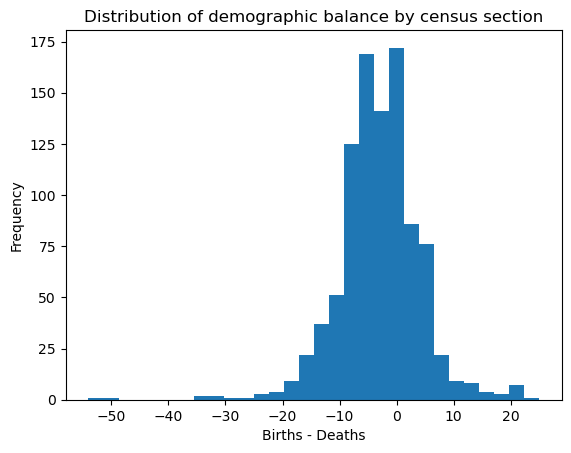

In [18]:
plt.hist(Defuncions_Naixements['Balanç Demogràfic'], bins=30)
plt.title("Distribution of demographic balance by census section")
plt.xlabel("Births - Deaths")
plt.ylabel("Frequency")
plt.show()

# Create a histogram of the demographic balance variable using 30 bins
# Add a title and axis labels to clearly describe the visualization
# Display the plot

From a general perspective, the histogram visually confirms what was previously observed through the mean and median: **most values lie below zero**, indicating that the demographic balance is predominantly negative.

Although the values are not extremely negative, this pattern suggests that **Barcelona’s population may be gradually aging**, as the number of deaths tends to exceed the number of births across most census sections.

**DEMOGRAPHIC BALANCE BY NEIGHBORHOOD**

At this stage, a custom function is created to summarize the demographic balance by neighborhood.

The objective is to group the data by neighborhood code and name, aggregate the number of births and deaths, and then compute the demographic balance for each neighborhood.

This approach provides a clearer view of **how the demographic balance varies across the different neighborhoods of Barcelona**.

In [19]:
def resum_per_barri(df):
    resum = df.groupby(["Codi_Barri", "Nom_Barri"]).agg(
        Naixements_tot=("Naixements", "sum"),
        Defuncions_tot=("Defuncions", "sum"))
    resum["Balanç_demogràfic"] = (resum["Naixements_tot"] - resum["Defuncions_tot"])
    return resum.reset_index()

In [20]:
# The function resum_per_barri() groups the data by neighborhood code (Codi_Barri) and name (Nom_Barri)
# and computes the total number of births and deaths for each neighborhood using aggregation.

# A new column is then created to represent the demographic balance (births minus deaths).

# Finally, reset_index() is applied to convert the grouped index into regular columns,
# resulting in a DataFrame that can be easily manipulated and visualized.

In [21]:
resum_barri = resum_per_barri(Defuncions_Naixements)
resum_barri.head()

# Apply the custom function and display the resulting DataFrame

,Codi_Barri,Nom_Barri,Naixements_tot,Defuncions_tot,Balanç_demogràfic
0,1,el Raval,415.0,231.0,184.0
1,10,Sant Antoni,248.0,334.0,-86.0
2,11,el Poble-sec,226.0,284.0,-58.0
3,12,la Marina del Prat Vermell,32.0,16.0,16.0
4,13,la Marina de Port,201.0,274.0,-73.0


In [22]:
resum_barri_ordenat = resum_barri.sort_values("Balanç_demogràfic")
resum_barri_ordenat.head()

# Sort the dataset by demographic balance to facilitate clearer and more informative visualizations

,Codi_Barri,Nom_Barri,Naixements_tot,Defuncions_tot,Balanç_demogràfic
56,60,Sant Andreu,263.0,488.0,-225.0
26,33,el Baix Guinardó,159.0,320.0,-161.0
55,6,la Sagrada Família,296.0,455.0,-159.0
71,8,l'Antiga Esquerra de l'Eixample,269.0,426.0,-157.0
72,9,la Nova Esquerra de l'Eixample,357.0,507.0,-150.0


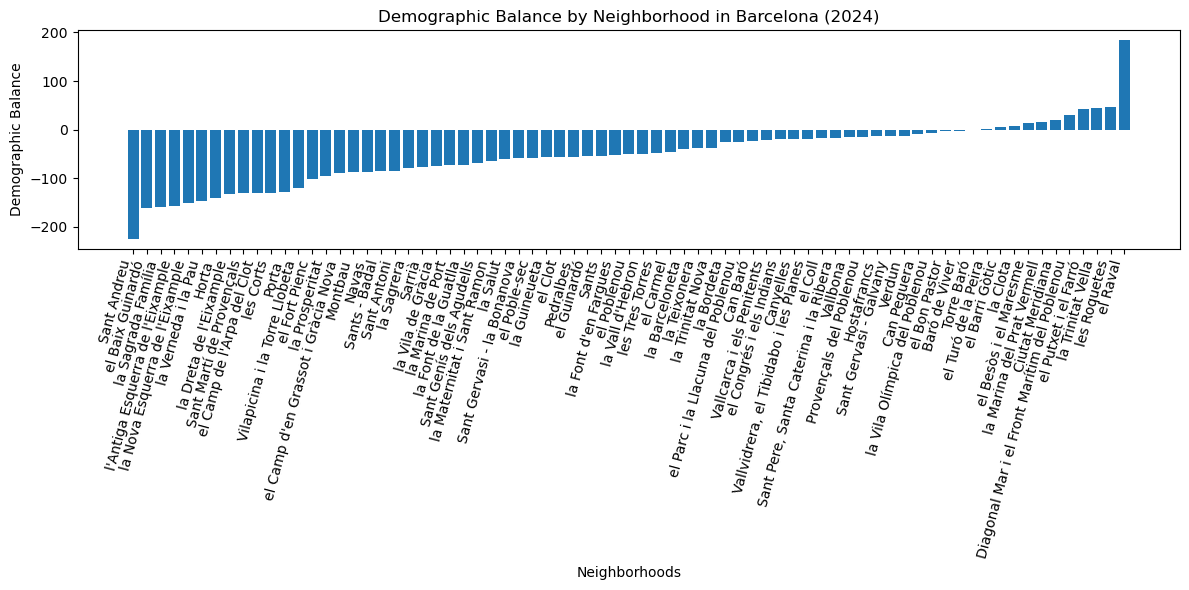

In [23]:
plt.figure(figsize=(12, 6))
plt.bar(resum_barri_ordenat['Nom_Barri'], resum_barri_ordenat['Balanç_demogràfic'])
plt.xticks(rotation=75, fontsize=10, ha="right")
plt.title("Demographic Balance by Neighborhood in Barcelona (2024)")
plt.ylabel("Demographic Balance")
plt.xlabel("Neighborhoods")
plt.tight_layout()

# Create a bar chart to visualize the demographic balance for each neighborhood
# Set a sufficiently large figure size to improve readability
# Plot neighborhoods on the x-axis and demographic balance on the y-axis
# Rotate x-axis labels for better visualization and adjust layout to prevent overlap
# Add title and axis labels to clearly describe the chart

Here, as can be clearly observed, in 2024, **all neighborhoods in Barcelona** show a **negative demographic balance**, **except**:

- **`El Raval`**
- **`les Roquetes`**
- **`la Trinitat Vella`**
- **`el Putxet i el Farró`**
- **`Diagonal Mar i el Front Marítim del Poblenou`**
- **`Ciutat Meridiana`**
- **`la Marina del Prat Vermell`**
- **`el Besòs i el Maresme`**
- **`la Clota`**
- **`el barri Gòtic`**
- **`el Turó de la Peira`**

**BIRTHS AND DEATHS / DEMOGRAPHIC BALANCE BY DISTRICT**

Here, we can take advantage of the smaller number of districts to display the total number of births and deaths per district.

Unlike the neighborhood-level analysis, where the large number of categories makes visualization less effective, the limited number of districts allows for a clearer and more interpretable bar plot.

In [24]:
neix_defu_districte = Defuncions_Naixements.groupby("Nom_Districte")[["Naixements", "Defuncions"]].sum()
neix_defu_districte.reset_index()

# Group data by district and compute the total number of births and deaths for each one
# This aggregation provides an overview of the overall demographic behavior by district
# reset_index() is used to convert the grouped index into regular columns for easier handling and interpretation

,Nom_Districte,Naixements,Defuncions
0,Ciutat Vella,721.0,587.0
1,Eixample,1664.0,2449.0
2,Gràcia,786.0,1049.0
3,Horta-Guinardó,1115.0,1827.0
4,Les Corts,537.0,787.0
5,Nou Barris,1187.0,1616.0
6,Sant Andreu,910.0,1283.0
7,Sant Martí,1492.0,2008.0
8,Sants-Montjuïc,1253.0,1622.0
9,Sarrià-Sant Gervasi,1193.0,1366.0


In [25]:
neix_defu = np.array([[721.0, 587.0],[1664.0, 2449.0],[786.0, 1049.0],[1115.0, 1827.0],
                      [537.0, 787.0],[1187.0, 1616.0],[910.0, 1283.0],[1492.0, 2008.0],
                      [1253.0, 1622.0],[1193.0, 1366.0]])

districtes = ["Ciutat Vella","Eixample","Gràcia","Horta-Guinardó","Les Corts","Nou Barris","Sant Andreu",
              "Sant Martí","Sants-Montjuïc","Sarrià-Sant Gervasi"]

# Data is structured as a NumPy array for efficient handling and plotting.

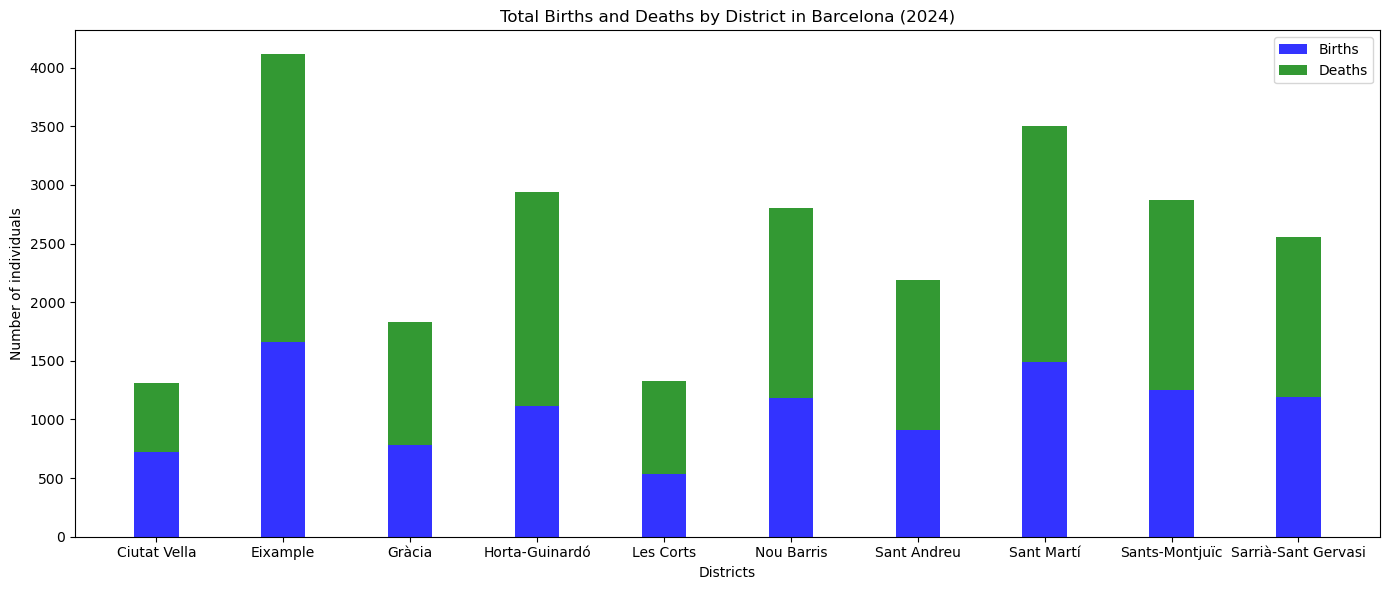

In [26]:
plt.figure(figsize=(14, 6))
index = np.arange(neix_defu.shape[0])
amplada = 0.35
opacitat = 0.8

naixements = plt.bar(index, neix_defu[::,0], amplada,
                     alpha=opacitat,
                     color='b',
                     label='Births')

defuncions = plt.bar(index, neix_defu[::,1], amplada, bottom=neix_defu[::,0],
                     alpha=opacitat,
                     color='g',
                     label='Deaths')

plt.title("Total Births and Deaths by District in Barcelona (2024)")
plt.xlabel("Districts")
plt.ylabel("Number of individuals")
plt.xticks(index, districtes)
plt.tight_layout()
plt.legend()
plt.show()

# Create a stacked bar chart to compare total births and deaths across districts
# Define figure size and create a numeric index for positioning the bars
# Set bar width and transparency for visual clarity
# Plot births first, then stack deaths on top using the 'bottom' parameter
# This allows visualization of both total values and category contributions
# Add title, axis labels, and district names on the x-axis
# Adjust layout, include legend, and display the plot

Aquí de nou, podem veure que la gran majoria de districtes tenen més defuncions que naixements, excepte **`Ciutat Vella`**.

In [27]:
neix_defu_districte = neix_defu_districte.reset_index()
neix_defu_districte["Balanç_demogràfic"] = (
    neix_defu_districte["Naixements"] - neix_defu_districte["Defuncions"]
)

# After grouping, reset_index() is used to convert the grouped index into regular columns
# Then, the demographic balance for each district is computed as births minus deaths
# This new variable summarizes the demographic growth or decline across districts

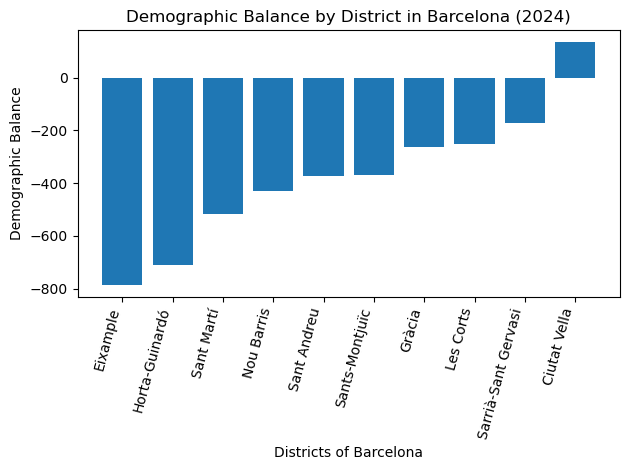

In [28]:
neix_defu_districte = neix_defu_districte.sort_values("Balanç_demogràfic")
plt.bar(neix_defu_districte['Nom_Districte'], neix_defu_districte['Balanç_demogràfic'])
plt.xticks(rotation=75, fontsize=10, ha="right")
plt.title("Demographic Balance by District in Barcelona (2024)")
plt.ylabel("Demographic Balance")
plt.xlabel("Districts of Barcelona")
plt.tight_layout()

# Sort the DataFrame by demographic balance to highlight differences across districts
# Create a bar chart with districts on the x-axis and their demographic balance on the y-axis
# Rotate x-axis labels to improve readability and adjust layout to prevent overlap
# Add title and axis labels to clearly describe the visualization

Finally, when analyzing the **demographic balance by district**, we observe that **all districts**, **except `Ciutat Vella`**, show **negative values**.

## CONCLUSIONS

The analysis conducted reveals a clear demographic reality in the city of Barcelona during 2024: the natural population balance is negative, both at the census-section level and when aggregated by neighborhoods and districts. In most areas, deaths exceed births, and only in a few cases do small positive balances appear, which do not offset the overall trend.

This demographic imbalance is not an isolated phenomenon. It is part of a broader dynamic observed in many European cities, characterized by population aging, declining birth rates, and a demographic structure that is progressively shifting towards maturity. While this analysis does not aim to establish causal relationships, it does provide a basis for reflection on the current situation and its potential implications: a sustained decrease in the young population, a relative increase in the elderly population, and, ultimately, growing pressure on the city’s social, economic, and healthcare systems.

This project, **modest yet rigorous**, highlights that Barcelona not only exhibits low birth rates, but also fails to offset deaths with new births, raising important challenges for the future. **Understanding these trends is essential to anticipate future needs, inform public policy, and reflect on the type of city we aim to build.**